#Descrição da Estratégia do Código
Abordagem Principal:
Esta é uma estratégia de trading quantitativo que age como um analista técnico seletivo em tempo integral. Seu objetivo é usar um modelo avançado de Machine Learning para tomar todas as decisões de compra, operando apenas quando a confiança em uma futura alta é suficientemente grande.

Filosofia de Funcionamento:

Visão Especializada: A estratégia reconhece que diferentes empresas são influenciadas por diferentes fatores. O CONFIGURACAO_ATIVOS garante que, para analisar a VALE3.SA, o modelo receba dados sobre minério de ferro e a economia chinesa, enquanto para o ITUB4.SA, ele receba dados sobre o mercado brasileiro em geral (Ibovespa).

Análise Técnica Avançada: Antes de o modelo de IA analisar os dados, a função engenharia_fatores calcula uma série de indicadores técnicos, como Momentum (força da tendência), Volatilidade (risco), RSI (para identificar se o ativo está "sobrecomprado" ou "sobrevendido") e a razão entre Médias Móveis (para confirmar tendências). Isso transforma os dados brutos de preço em uma visão muito mais rica do "comportamento" do ativo, permitindo que a IA identifique padrões complexos.

Aprendizado Otimizado: O coração da inteligência é a função otimizar_modelo_xgb. Ela não usa um modelo qualquer, mas sim o XGBoost, famoso por sua performance. Mais importante, ela usa GridSearchCV e TimeSeriesSplit para testar exaustivamente várias "versões" do cérebro da IA e escolher a que teve o melhor desempenho de aprendizado, garantindo que o modelo seja o mais preciso possível para os dados históricos.

Decisão Estratégica (Não Fixa): A decisão de comprar não é uma regra simples. A função otimizar_limiar executa um "simulado" em um período de validação para descobrir qual o "nível de confiança" (limiar) ideal para operar. Isso torna a estratégia adaptativa, pois o limiar de decisão é calibrado de acordo com as características do modelo e dos dados, em vez de ser um valor fixo.

Em Resumo:

É uma abordagem sofisticada e cautelosa. Ela combina a especialização (fatores corretos para cada ativo) com uma análise técnica profunda (indicadores) e um processo de aprendizado e decisão em duas etapas (otimização do modelo + otimização da estratégia). Seu ponto forte é a capacidade de proteger o capital em mercados desafiadores, ao custo de, por vezes, ser conservadora demais em mercados de alta muito intensa.

In [1]:
# ====================================================================
# CÉLULA 1: INSTALAÇÃO E IMPORTAÇÕES
# ====================================================================

# Garante que todas as bibliotecas necessárias para o projeto estejam instaladas no ambiente.
!pip install yfinance pandas scikit-learn xgboost ta matplotlib --user

# Importa as bibliotecas para manipulação de dados, tempo e sistema operacional.
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
import numpy as np
import os

# Importa as ferramentas para criação e visualização de gráficos.
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Importa as ferramentas de Machine Learning.
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import classification_report
import xgboost as xgb

# Importa a biblioteca para cálculo de indicadores de análise técnica.
import ta

In [2]:
# ====================================================================
# CÉLULA 2: PAINEL DE CONTROLE (CONFIGURAÇÕES)
# ====================================================================

# --- CONFIGURAÇÃO DOS ATIVOS (FATORES ESPECÍFICOS) ---
CONFIGURACAO_ATIVOS = {
    "VALE3.SA": {
        "setor": "Mineração (Global)",
        "fatores": ['SI=F', 'MCHI', 'BRL=X', 'CL=F'], 
        "nomes": ['Preco_Minerio_Ferro', 'ETF_China', 'Taxa_Cambio_USD_BRL', 'Preco_Petroleo']
    },
    "ITUB4.SA": {
        "setor": "Bancário (Nacional)",
        "fatores": ['^BVSP', 'EWZ', 'BRL=X'], 
        "nomes": ['Indice_Ibovespa', 'ETF_Brasil', 'Taxa_Cambio_USD_BRL']
    },
    "LREN3.SA": {
        "setor": "Varejo (Nacional)",
        "fatores": ['^BVSP', 'EWZ', 'BRL=X'],
        "nomes": ['Indice_Ibovespa', 'ETF_Brasil', 'Taxa_Cambio_USD_BRL']
    },
    "ELET3.SA": {
        "setor": "Elétrico (Utilities)",
        "fatores": ['^BVSP', 'EWZ', 'BRL=X'],
        "nomes": ['Indice_Ibovespa', 'ETF_Brasil', 'Taxa_Cambio_USD_BRL']
    },
    "RADL3.SA": {
        "setor": "Saúde/Varejo Farma",
        "fatores": ['^BVSP', 'EWZ', 'BRL=X'],
        "nomes": ['Indice_Ibovespa', 'ETF_Brasil', 'Taxa_Cambio_USD_BRL']
    }
}

# --- CONFIGURAÇÃO DOS CENÁRIOS DE TEMPO ---
CENARIOS_DE_TESTE = {
    "Crise COVID-19": {
        "data_inicio_geral": datetime(2017, 6, 1), # Antes era 2018, 1, 1
        "data_fim_treino": datetime(2019, 12, 31),
        "data_fim_validacao": datetime(2020, 6, 30),
        "data_fim_teste": datetime(2020, 12, 31),
    },
    "Mercado de Alta Pós-Pandemia": {
        "data_inicio_geral": datetime(2018, 6, 1), # Antes era 2019, 1, 1
        "data_fim_treino": datetime(2020, 12, 31),
        "data_fim_validacao": datetime(2021, 6, 30),
        "data_fim_teste": datetime(2021, 12, 31),
    },
    "Mercado Desafiador (Juros Altos)": {
        "data_inicio_geral": datetime(2019, 6, 1), # Antes era 2020, 1, 1
        "data_fim_treino": datetime(2021, 12, 31),
        "data_fim_validacao": datetime(2022, 6, 30),
        "data_fim_teste": datetime(2022, 12, 31),
    },
}

# --- CONFIGURAÇÃO DOS ATIVOS A SEREM TESTADOS ---
LISTA_DE_ATIVOS = ['VALE3.SA', 'ITUB4.SA', 'LREN3.SA', 'ELET3.SA', 'RADL3.SA']

In [3]:
# ====================================================================
# CÉLULA 3: FUNÇÕES DO SISTEMA (O MOTOR DA ANÁLISE)
# ====================================================================

def coletar_dados(ticker, fatores, nomes_fatores, start, end):
    print(f"--- Coletando dados para {ticker} de {start.date()} a {end.date()} ---")
    todos_tickers = list(set([ticker] + fatores))
    dados = yf.download(todos_tickers, start=start, end=end, progress=False, auto_adjust=True)
    if dados.empty or ticker not in dados['Close'].columns or dados['Close'][ticker].isnull().all():
        print(f"Erro: Falha ao baixar dados para o ticker principal {ticker}.")
        return pd.DataFrame()
    df = pd.DataFrame(index=dados.index)
    df['Preco_Fechamento'] = dados['Close'][ticker]
    df['Volume'] = dados['Volume'][ticker]
    for fator, nome in zip(fatores, nomes_fatores):
        if fator in dados['Close'].columns and not dados['Close'][fator].isnull().all(): 
            df[nome] = dados['Close'][fator]
        else: 
            print(f"Aviso: Não foi possível baixar ou dados vazios para o fator '{nome}' ({fator}). A coluna será preenchida.")
            df[nome] = np.nan
    return df

def engenharia_fatores(df):
    print("--- Realizando engenharia de fatores ---")
    df.ffill(inplace=True)
    if df.empty: return df
    df['Retorno_1d'] = df['Preco_Fechamento'].pct_change()
    df['Retorno_Futuro'] = df['Retorno_1d'].shift(-1)
    df['Momentum_5d'] = df['Preco_Fechamento'].pct_change(5)
    df['Volatilidade_10d'] = df['Retorno_1d'].rolling(window=10).std()
    df['RSI_14d'] = ta.momentum.RSIIndicator(close=df['Preco_Fechamento'], window=14).rsi()
    df['SMA_10_50_Ratio'] = ta.trend.SMAIndicator(df['Preco_Fechamento'], window=10).sma_indicator() / ta.trend.SMAIndicator(df['Preco_Fechamento'], window=50).sma_indicator()
    df.dropna(inplace=True)
    if df.empty:
        print("ERRO CRÍTICO: DataFrame ficou vazio.")
        return df
        
    # <-- MUDANÇA: Transformando o alvo em multiclasse
    conditions = [
        (df['Retorno_Futuro'] > 0.02),                   # Forte Alta (> 2%)
        (df['Retorno_Futuro'] > 0.002),                  # Alta Normal (> 0.2%)
    ]
    choices = [2, 1] # 2: Forte Alta, 1: Alta Normal
    # O padrão (default) é 0, representando Neutra/Queda.
    df['Target'] = np.select(conditions, choices, default=0)
    
    return df

def otimizar_modelo_xgb(df_treino, features, target):
    print("--- Otimizando hiperparâmetros do XGBoost Multiclasse... ---")
    X_treino = df_treino[features]
    y_treino = df_treino[target]
    if X_treino.empty: return None, None
    
    scaler = StandardScaler()
    X_treino_scaled = scaler.fit_transform(X_treino)
    
    tscv = TimeSeriesSplit(n_splits=3)
    param_grid = {"max_depth": [3, 5], "n_estimators": [100, 200], "learning_rate": [0.05, 0.1]}
    xgb_model = xgb.XGBClassifier(
        objective='multi:softprob', # Objetivo para múltiplas classes
        num_class=3,                # Número de classes: 0, 1, 2
        use_label_encoder=False, 
        verbosity=0, 
        eval_metric='mlogloss', 
        random_state=42
    )
    
    gsearch = GridSearchCV(xgb_model, param_grid, cv=tscv, scoring='accuracy', n_jobs=-1)
    gsearch.fit(X_treino_scaled, y_treino)
    
    print(f"Melhores parâmetros: {gsearch.best_params_}")
    return gsearch.best_estimator_, scaler

def executar_backtest(modelo, scaler, df_teste, features, ticker, cenario):
    print("--- Executando backtest final ---")
    if df_teste.empty:
        print("ERRO: Conjunto de teste vazio.")
        return None

    # O modelo agora prevê a classe diretamente (0, 1 ou 2)
    X_teste_scaled = scaler.transform(df_teste[features])
    predicoes = modelo.predict(X_teste_scaled)
    
    # A regra de negócio agora é: comprar se a previsão for Alta (1) ou Forte Alta (2)
    sinais = np.where(predicoes > 0, 1, 0)
    df_teste['Sinal_IA'] = sinais
    
    capital_inicial = 1000
    df_teste['Retorno_Estrategia'] = df_teste['Retorno_Futuro'] * df_teste['Sinal_IA']
    df_teste['Capital_Estrategia'] = capital_inicial * (1 + df_teste['Retorno_Estrategia']).cumprod()
    df_teste['Capital_Benchmark'] = capital_inicial * (1 + df_teste['Retorno_Futuro']).cumprod()
    
    lucro_ia = df_teste['Capital_Estrategia'].iloc[-1] - capital_inicial
    lucro_benchmark = df_teste['Capital_Benchmark'].iloc[-1] - capital_inicial
    
    print("\n" + "-"*40)
    print(f"RESULTADO FINANCEIRO: {ticker} | Cenário: {cenario}")
    print(f"Período de Teste: {df_teste.index.min().date()} a {df_teste.index.max().date()}")
    print(f"Lucro/Perda da Estratégia IA: R$ {lucro_ia:.2f}")
    print(f"Lucro/Perda do Benchmark (Buy & Hold): R$ {lucro_benchmark:.2f}")
    print("-"*40)

    plt.figure(figsize=(14, 7))
    plt.plot(df_teste.index, df_teste['Capital_Estrategia'], label='Estratégia IA')
    plt.plot(df_teste.index, df_teste['Capital_Benchmark'], label='Benchmark (Buy & Hold)', linestyle='--')
    plt.title(f'Desempenho para {ticker} no Cenário "{cenario}"')
    plt.xlabel('Data')
    plt.ylabel('Capital Acumulado (R$)')
    plt.legend()
    plt.grid(True)
    nome_arquivo = f"resultado_{ticker}_{cenario.replace(' ', '_')}.png"
    plt.savefig(nome_arquivo)
    print(f"\nGráfico salvo como '{nome_arquivo}'")
    plt.show()
    return df_teste

def avaliar_performance_modelo(df_resultado, target):
    if df_resultado is None or df_resultado.empty:
        return
    
    y_true = df_resultado[target]
    # Como a decisão de compra é para classes > 0, ajustamos a predição para ser binária.
    y_pred = df_resultado['Sinal_IA']
    
    print("\n" + "-"*40)
    print(f"MÉTRICAS DE CLASSIFICAÇÃO (Decisão de Comprar vs Não Comprar)")
    # O relatório agora avalia a decisão final de COMPRAR (1) vs NÃO COMPRAR (0)
    report = classification_report(y_true > 0, y_pred, target_names=['Não Compra', 'Compra'], zero_division=0)
    print(report)
    print("-"*40)

# <-- NOVA FUNÇÃO ---
def analisar_feature_importance(modelo, features, ticker, cenario):
    """
    Exibe a importância de cada fator (feature) para as decisões do modelo.
    """
    if modelo is None:
        return
        
    importances = modelo.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
    
    print("\n" + "-"*40)
    print(f"IMPORTÂNCIA DOS FATORES: {ticker} | {cenario}")
    print(feature_importance_df)
    print("-"*40)
    
    # Salva também a importância dos fatores em um dicionário para análise final
    return {
        'ativo': ticker,
        'cenario': cenario,
        'importancias': feature_importance_df
    }


========= EXECUTANDO CENÁRIO: 'Crise COVID-19' PARA O ATIVO: VALE3.SA ==========
--- Coletando dados para VALE3.SA de 2017-06-01 a 2020-12-31 ---
--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost Multiclasse... ---
Melhores parâmetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
--- Executando backtest final ---

----------------------------------------
RESULTADO FINANCEIRO: VALE3.SA | Cenário: Crise COVID-19
Período de Teste: 2020-07-01 a 2020-12-29
Lucro/Perda da Estratégia IA: R$ -2.94
Lucro/Perda do Benchmark (Buy & Hold): R$ 670.44
----------------------------------------

Gráfico salvo como 'resultado_VALE3.SA_Crise_COVID-19.png'


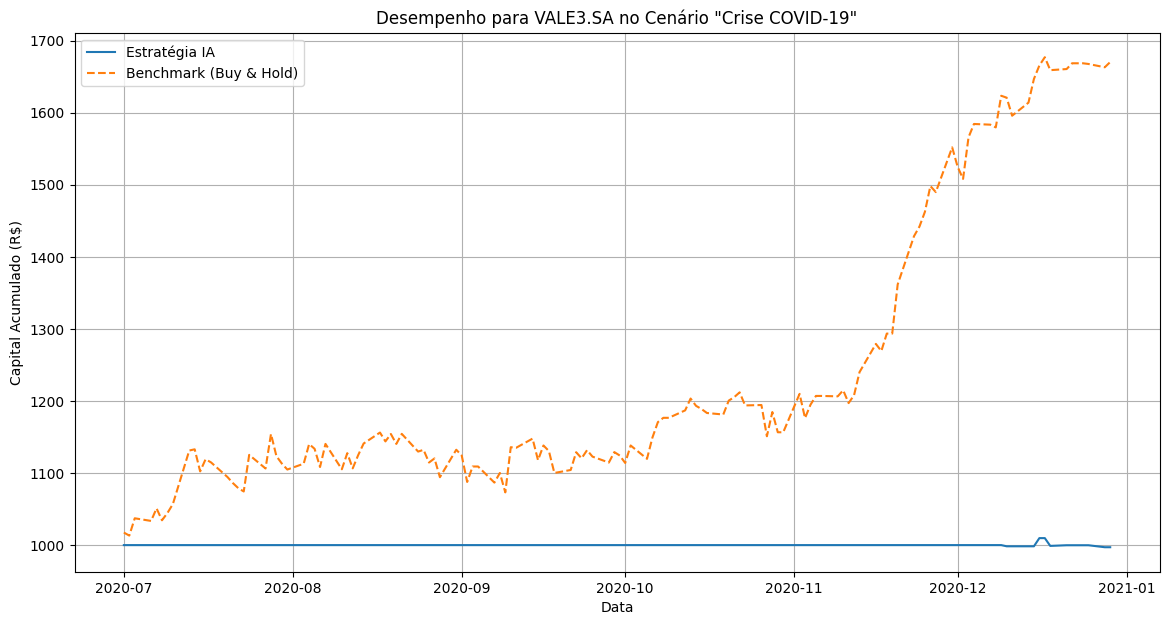


----------------------------------------
IMPORTÂNCIA DOS FATORES: VALE3.SA | Crise COVID-19
               Feature  Importance
4               Volume    0.139718
3      SMA_10_50_Ratio    0.136355
0          Momentum_5d    0.121569
1     Volatilidade_10d    0.112150
6            ETF_China    0.104967
8       Preco_Petroleo    0.102455
5  Preco_Minerio_Ferro    0.101636
7  Taxa_Cambio_USD_BRL    0.095116
2              RSI_14d    0.086034
----------------------------------------

========= EXECUTANDO CENÁRIO: 'Crise COVID-19' PARA O ATIVO: ITUB4.SA ==========
--- Coletando dados para ITUB4.SA de 2017-06-01 a 2020-12-31 ---
--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost Multiclasse... ---
Melhores parâmetros: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
--- Executando backtest final ---

----------------------------------------
RESULTADO FINANCEIRO: ITUB4.SA | Cenário: Crise COVID-19
Período de Teste: 2020-07-01 a 2020-12-29
Lucro/Perd

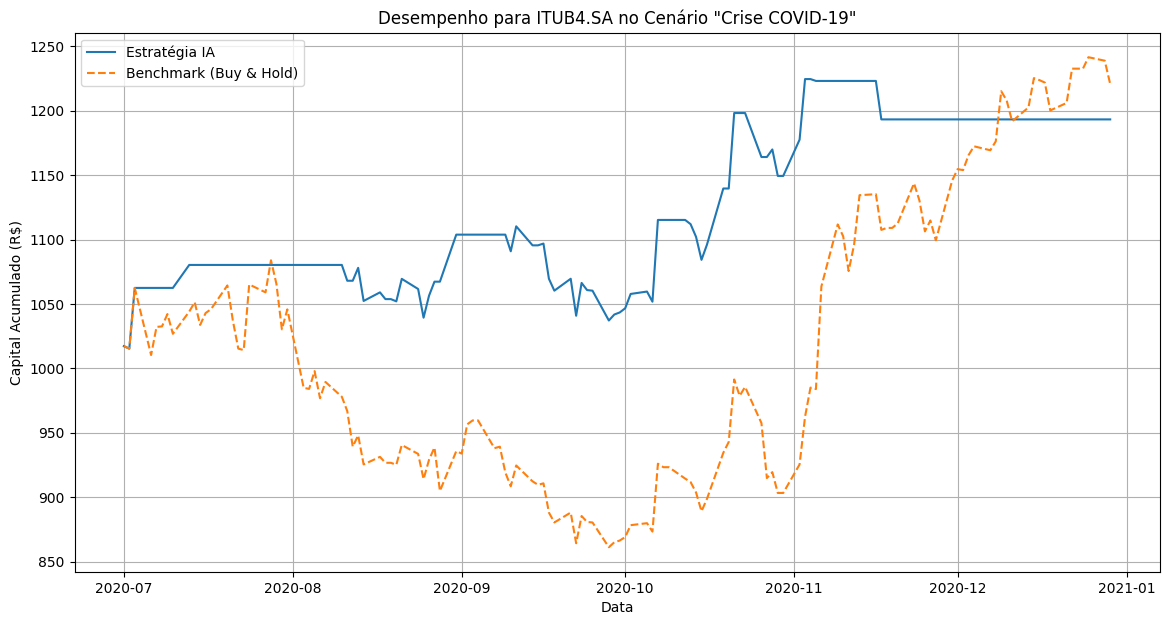


----------------------------------------
IMPORTÂNCIA DOS FATORES: ITUB4.SA | Crise COVID-19
               Feature  Importance
7  Taxa_Cambio_USD_BRL    0.148913
6           ETF_Brasil    0.147705
5      Indice_Ibovespa    0.129807
3      SMA_10_50_Ratio    0.122792
2              RSI_14d    0.116220
1     Volatilidade_10d    0.115190
0          Momentum_5d    0.110985
4               Volume    0.108388
----------------------------------------

========= EXECUTANDO CENÁRIO: 'Crise COVID-19' PARA O ATIVO: LREN3.SA ==========
--- Coletando dados para LREN3.SA de 2017-06-01 a 2020-12-31 ---
--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost Multiclasse... ---
Melhores parâmetros: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
--- Executando backtest final ---

----------------------------------------
RESULTADO FINANCEIRO: LREN3.SA | Cenário: Crise COVID-19
Período de Teste: 2020-07-01 a 2020-12-29
Lucro/Perda da Estratégia IA: R$ 77.50
Lucro/

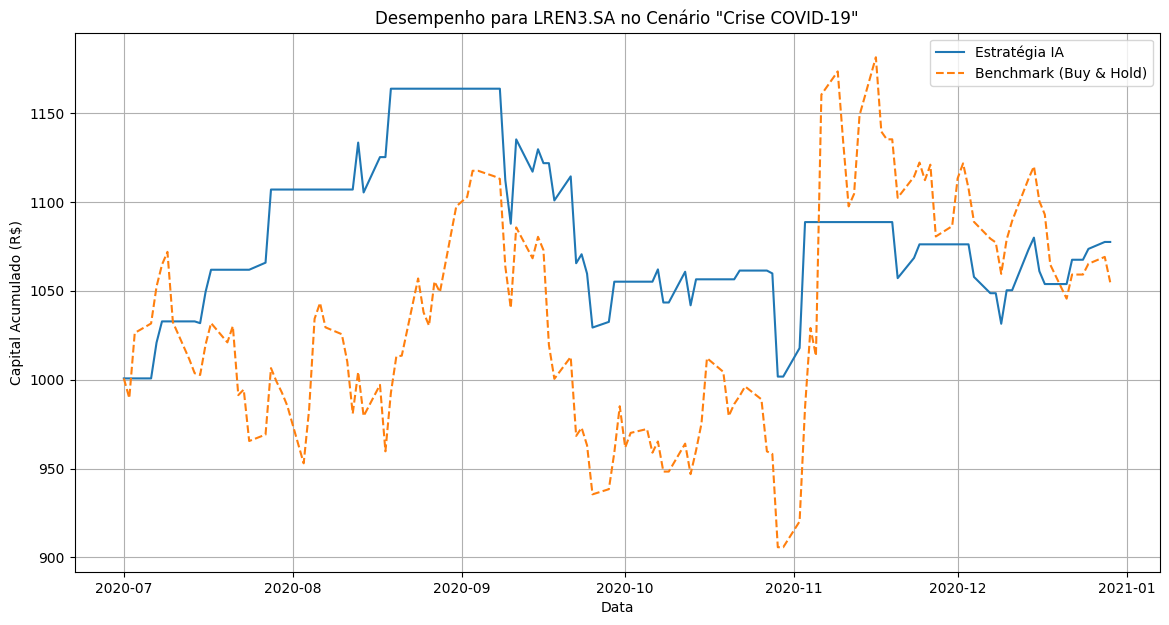


----------------------------------------
IMPORTÂNCIA DOS FATORES: LREN3.SA | Crise COVID-19
               Feature  Importance
0          Momentum_5d    0.137547
3      SMA_10_50_Ratio    0.136201
2              RSI_14d    0.125854
5      Indice_Ibovespa    0.123175
7  Taxa_Cambio_USD_BRL    0.121599
6           ETF_Brasil    0.119730
4               Volume    0.119256
1     Volatilidade_10d    0.116638
----------------------------------------

========= EXECUTANDO CENÁRIO: 'Crise COVID-19' PARA O ATIVO: ELET3.SA ==========
--- Coletando dados para ELET3.SA de 2017-06-01 a 2020-12-31 ---
--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost Multiclasse... ---
Melhores parâmetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
--- Executando backtest final ---

----------------------------------------
RESULTADO FINANCEIRO: ELET3.SA | Cenário: Crise COVID-19
Período de Teste: 2020-07-01 a 2020-12-29
Lucro/Perda da Estratégia IA: R$ 313.22
Lucro

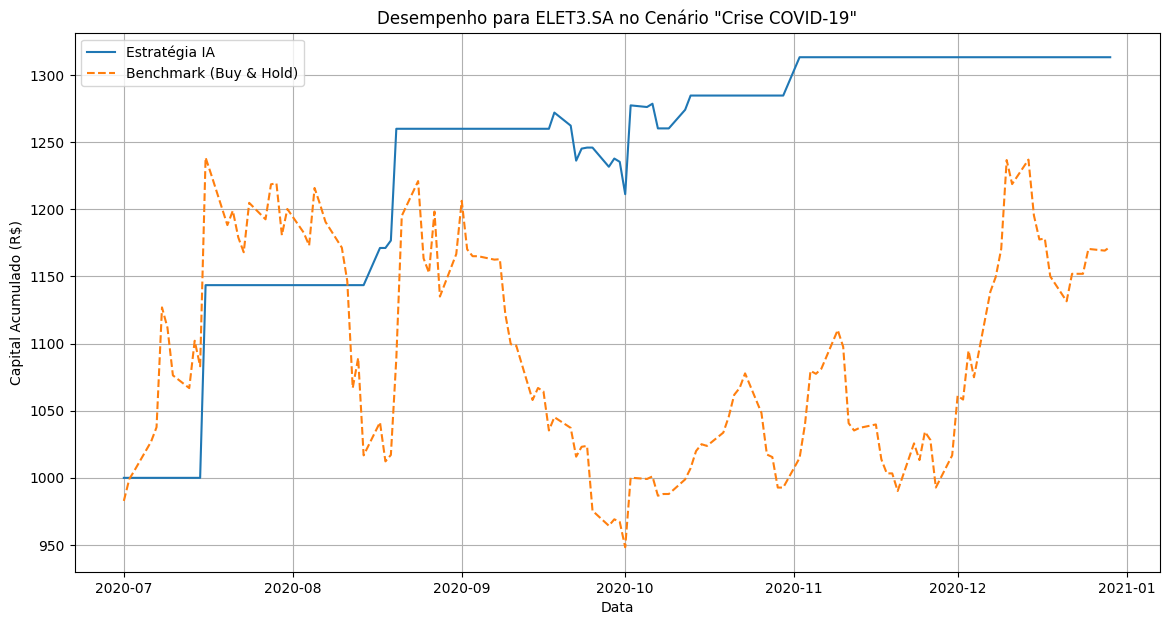


----------------------------------------
IMPORTÂNCIA DOS FATORES: ELET3.SA | Crise COVID-19
               Feature  Importance
6           ETF_Brasil    0.147617
0          Momentum_5d    0.139309
7  Taxa_Cambio_USD_BRL    0.133527
1     Volatilidade_10d    0.125557
5      Indice_Ibovespa    0.117490
3      SMA_10_50_Ratio    0.113493
4               Volume    0.111637
2              RSI_14d    0.111371
----------------------------------------

========= EXECUTANDO CENÁRIO: 'Crise COVID-19' PARA O ATIVO: RADL3.SA ==========
--- Coletando dados para RADL3.SA de 2017-06-01 a 2020-12-31 ---
--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost Multiclasse... ---
Melhores parâmetros: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
--- Executando backtest final ---

----------------------------------------
RESULTADO FINANCEIRO: RADL3.SA | Cenário: Crise COVID-19
Período de Teste: 2020-07-01 a 2020-12-29
Lucro/Perda da Estratégia IA: R$ 57.23
Lucro/

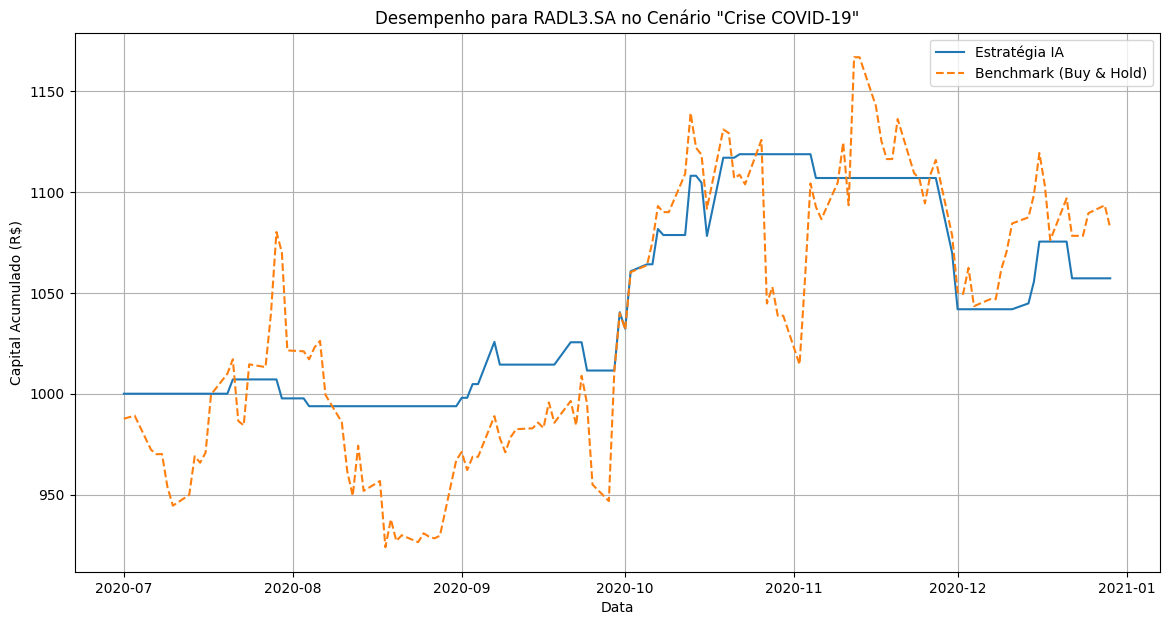


----------------------------------------
IMPORTÂNCIA DOS FATORES: RADL3.SA | Crise COVID-19
               Feature  Importance
5      Indice_Ibovespa    0.145196
2              RSI_14d    0.125363
1     Volatilidade_10d    0.125295
4               Volume    0.124938
7  Taxa_Cambio_USD_BRL    0.120719
3      SMA_10_50_Ratio    0.120314
0          Momentum_5d    0.119364
6           ETF_Brasil    0.118811
----------------------------------------

== EXECUTANDO CENÁRIO: 'Mercado de Alta Pós-Pandemia' PARA O ATIVO: VALE3.SA ===
--- Coletando dados para VALE3.SA de 2018-06-01 a 2021-12-31 ---
--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost Multiclasse... ---
Melhores parâmetros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
--- Executando backtest final ---

----------------------------------------
RESULTADO FINANCEIRO: VALE3.SA | Cenário: Mercado de Alta Pós-Pandemia
Período de Teste: 2021-07-01 a 2021-12-29
Lucro/Perda da Estratégia IA: R$

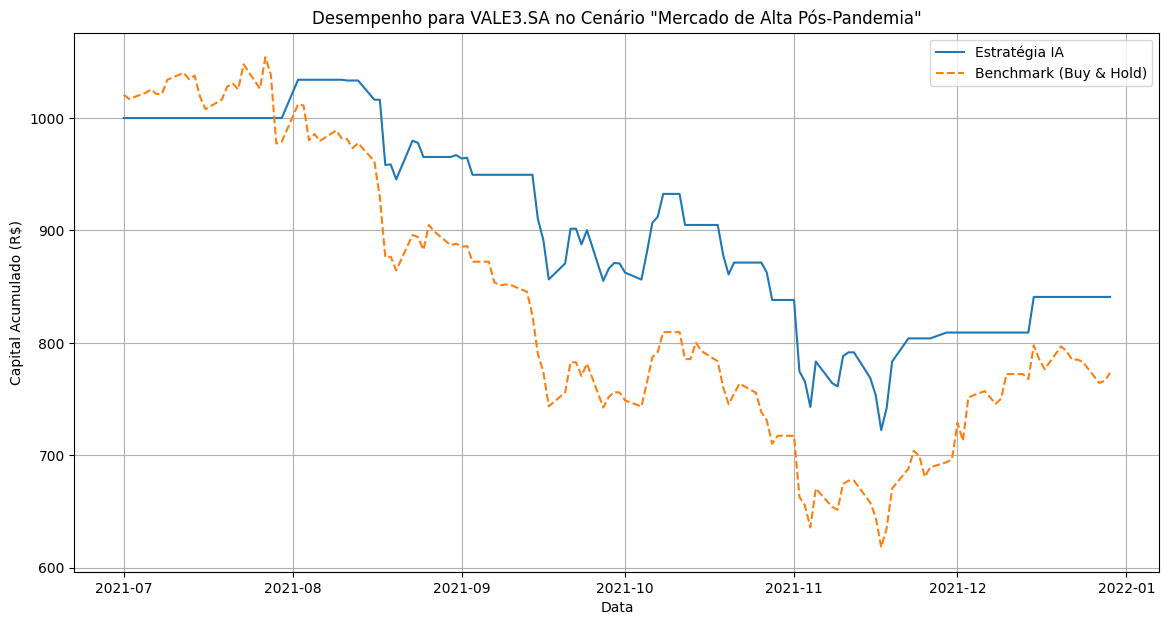


----------------------------------------
IMPORTÂNCIA DOS FATORES: VALE3.SA | Mercado de Alta Pós-Pandemia
               Feature  Importance
8       Preco_Petroleo    0.125922
4               Volume    0.121201
0          Momentum_5d    0.120428
5  Preco_Minerio_Ferro    0.117868
3      SMA_10_50_Ratio    0.117225
1     Volatilidade_10d    0.109678
6            ETF_China    0.104226
2              RSI_14d    0.103546
7  Taxa_Cambio_USD_BRL    0.079905
----------------------------------------

== EXECUTANDO CENÁRIO: 'Mercado de Alta Pós-Pandemia' PARA O ATIVO: ITUB4.SA ===
--- Coletando dados para ITUB4.SA de 2018-06-01 a 2021-12-31 ---
--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost Multiclasse... ---
Melhores parâmetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
--- Executando backtest final ---

----------------------------------------
RESULTADO FINANCEIRO: ITUB4.SA | Cenário: Mercado de Alta Pós-Pandemia
Período de Teste: 2021-0

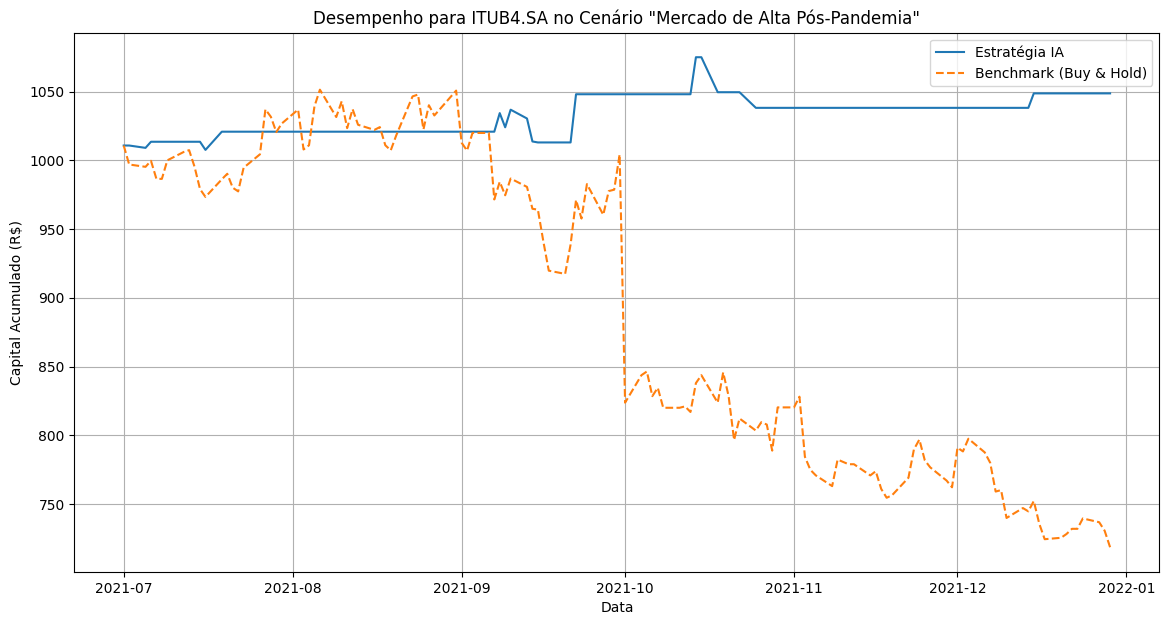


----------------------------------------
IMPORTÂNCIA DOS FATORES: ITUB4.SA | Mercado de Alta Pós-Pandemia
               Feature  Importance
6           ETF_Brasil    0.187272
2              RSI_14d    0.131652
5      Indice_Ibovespa    0.131635
7  Taxa_Cambio_USD_BRL    0.119303
4               Volume    0.115353
1     Volatilidade_10d    0.109794
3      SMA_10_50_Ratio    0.106105
0          Momentum_5d    0.098886
----------------------------------------

== EXECUTANDO CENÁRIO: 'Mercado de Alta Pós-Pandemia' PARA O ATIVO: LREN3.SA ===
--- Coletando dados para LREN3.SA de 2018-06-01 a 2021-12-31 ---
--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost Multiclasse... ---
Melhores parâmetros: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
--- Executando backtest final ---

----------------------------------------
RESULTADO FINANCEIRO: LREN3.SA | Cenário: Mercado de Alta Pós-Pandemia
Período de Teste: 2021-07-01 a 2021-12-29
Lucro/Perda da Es

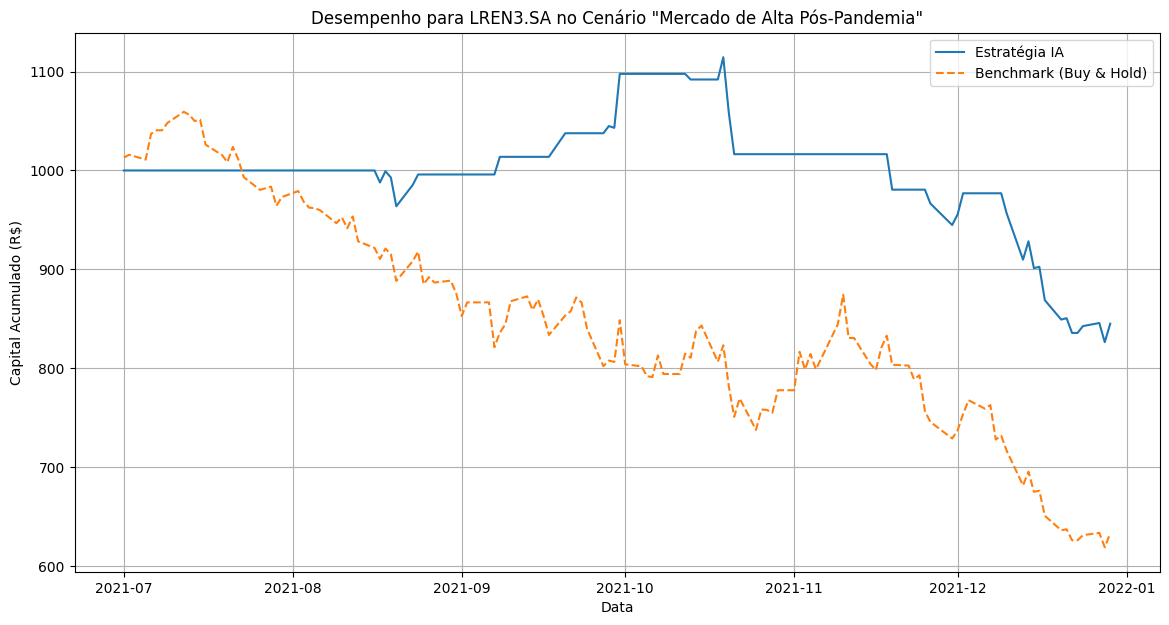


----------------------------------------
IMPORTÂNCIA DOS FATORES: LREN3.SA | Mercado de Alta Pós-Pandemia
               Feature  Importance
5      Indice_Ibovespa    0.177470
1     Volatilidade_10d    0.132332
4               Volume    0.119653
3      SMA_10_50_Ratio    0.119520
2              RSI_14d    0.117443
0          Momentum_5d    0.117370
6           ETF_Brasil    0.108700
7  Taxa_Cambio_USD_BRL    0.107511
----------------------------------------

== EXECUTANDO CENÁRIO: 'Mercado de Alta Pós-Pandemia' PARA O ATIVO: ELET3.SA ===
--- Coletando dados para ELET3.SA de 2018-06-01 a 2021-12-31 ---
--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost Multiclasse... ---
Melhores parâmetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
--- Executando backtest final ---

----------------------------------------
RESULTADO FINANCEIRO: ELET3.SA | Cenário: Mercado de Alta Pós-Pandemia
Período de Teste: 2021-07-01 a 2021-12-29
Lucro/Perda da Es

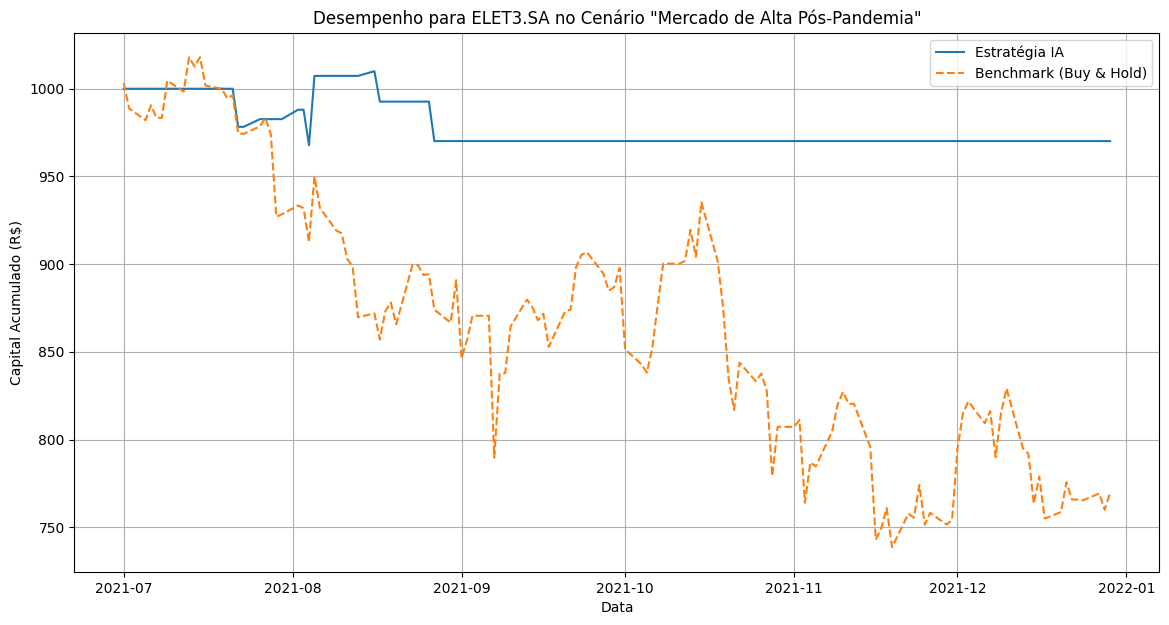


----------------------------------------
IMPORTÂNCIA DOS FATORES: ELET3.SA | Mercado de Alta Pós-Pandemia
               Feature  Importance
1     Volatilidade_10d    0.174235
5      Indice_Ibovespa    0.148756
6           ETF_Brasil    0.144189
3      SMA_10_50_Ratio    0.110694
0          Momentum_5d    0.109840
4               Volume    0.108180
2              RSI_14d    0.102926
7  Taxa_Cambio_USD_BRL    0.101180
----------------------------------------

== EXECUTANDO CENÁRIO: 'Mercado de Alta Pós-Pandemia' PARA O ATIVO: RADL3.SA ===
--- Coletando dados para RADL3.SA de 2018-06-01 a 2021-12-31 ---
--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost Multiclasse... ---
Melhores parâmetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
--- Executando backtest final ---

----------------------------------------
RESULTADO FINANCEIRO: RADL3.SA | Cenário: Mercado de Alta Pós-Pandemia
Período de Teste: 2021-07-01 a 2021-12-29
Lucro/Perda da Es

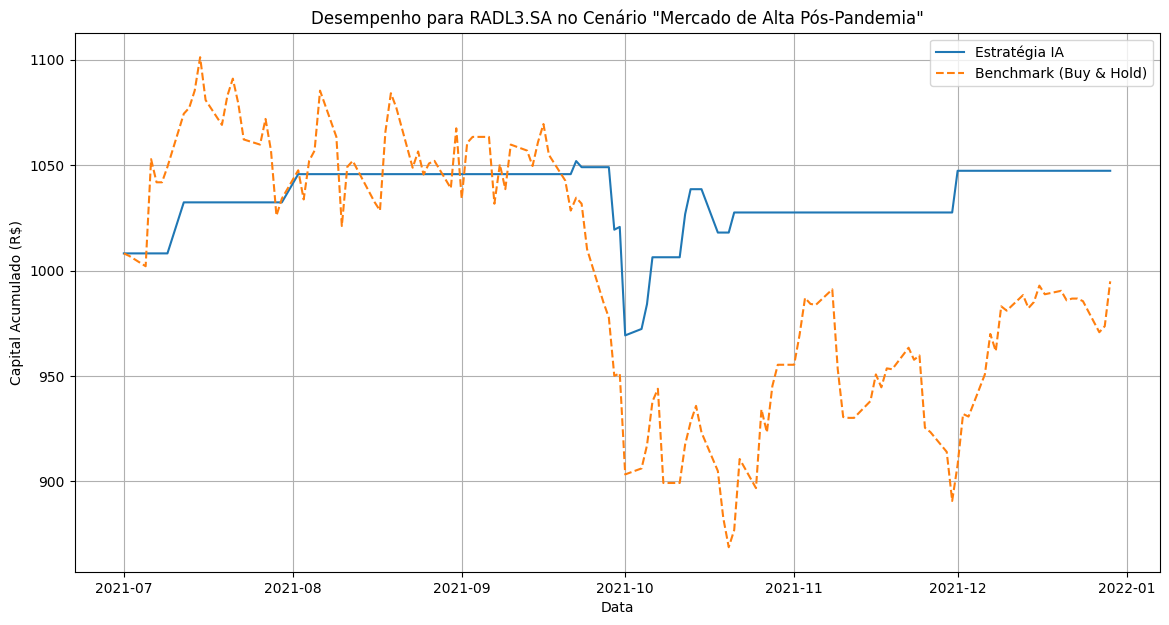


----------------------------------------
IMPORTÂNCIA DOS FATORES: RADL3.SA | Mercado de Alta Pós-Pandemia
               Feature  Importance
6           ETF_Brasil    0.147392
5      Indice_Ibovespa    0.142165
2              RSI_14d    0.127616
1     Volatilidade_10d    0.125786
3      SMA_10_50_Ratio    0.119834
7  Taxa_Cambio_USD_BRL    0.119764
4               Volume    0.110754
0          Momentum_5d    0.106688
----------------------------------------

 EXECUTANDO CENÁRIO: 'Mercado Desafiador (Juros Altos)' PARA O ATIVO: VALE3.SA =
--- Coletando dados para VALE3.SA de 2019-06-01 a 2022-12-31 ---
--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost Multiclasse... ---
Melhores parâmetros: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
--- Executando backtest final ---

----------------------------------------
RESULTADO FINANCEIRO: VALE3.SA | Cenário: Mercado Desafiador (Juros Altos)
Período de Teste: 2022-07-01 a 2022-12-29
Lucro/Perda da

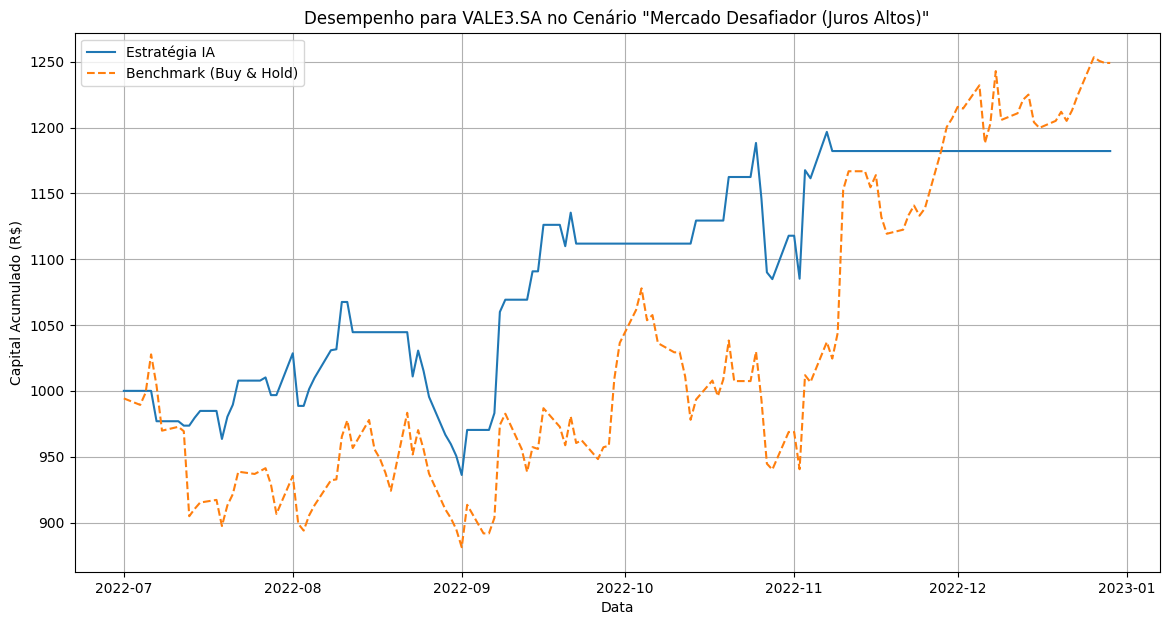


----------------------------------------
IMPORTÂNCIA DOS FATORES: VALE3.SA | Mercado Desafiador (Juros Altos)
               Feature  Importance
2              RSI_14d    0.120001
3      SMA_10_50_Ratio    0.118454
6            ETF_China    0.118041
1     Volatilidade_10d    0.117971
7  Taxa_Cambio_USD_BRL    0.109159
5  Preco_Minerio_Ferro    0.105675
4               Volume    0.105026
8       Preco_Petroleo    0.104612
0          Momentum_5d    0.101062
----------------------------------------

 EXECUTANDO CENÁRIO: 'Mercado Desafiador (Juros Altos)' PARA O ATIVO: ITUB4.SA =
--- Coletando dados para ITUB4.SA de 2019-06-01 a 2022-12-31 ---
--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost Multiclasse... ---
Melhores parâmetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
--- Executando backtest final ---

----------------------------------------
RESULTADO FINANCEIRO: ITUB4.SA | Cenário: Mercado Desafiador (Juros Altos)
Período de Teste

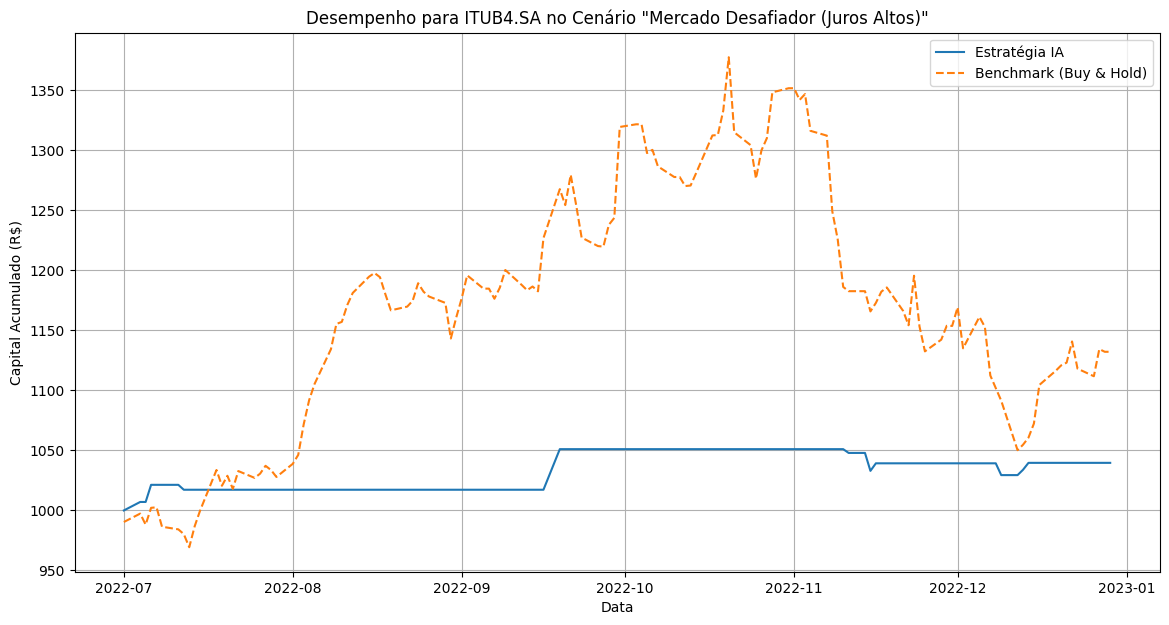


----------------------------------------
IMPORTÂNCIA DOS FATORES: ITUB4.SA | Mercado Desafiador (Juros Altos)
               Feature  Importance
5      Indice_Ibovespa    0.154606
2              RSI_14d    0.134903
7  Taxa_Cambio_USD_BRL    0.130169
4               Volume    0.123491
0          Momentum_5d    0.123252
3      SMA_10_50_Ratio    0.122916
6           ETF_Brasil    0.115643
1     Volatilidade_10d    0.095020
----------------------------------------

 EXECUTANDO CENÁRIO: 'Mercado Desafiador (Juros Altos)' PARA O ATIVO: LREN3.SA =
--- Coletando dados para LREN3.SA de 2019-06-01 a 2022-12-31 ---
--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost Multiclasse... ---
Melhores parâmetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
--- Executando backtest final ---

----------------------------------------
RESULTADO FINANCEIRO: LREN3.SA | Cenário: Mercado Desafiador (Juros Altos)
Período de Teste: 2022-07-01 a 2022-12-29
Lucro/Per

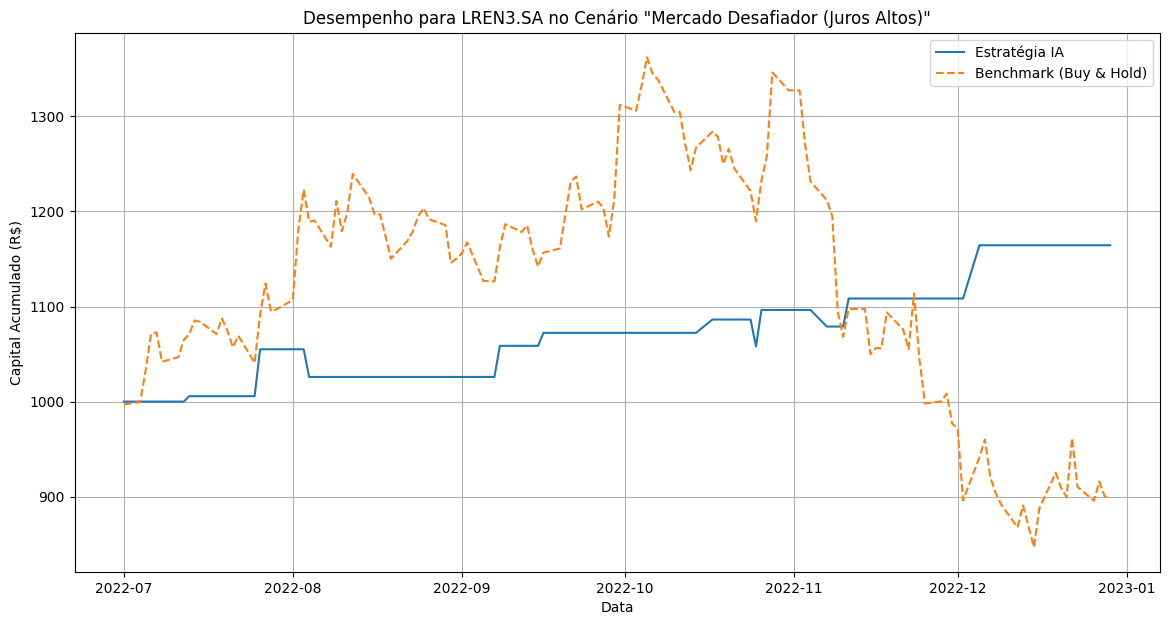


----------------------------------------
IMPORTÂNCIA DOS FATORES: LREN3.SA | Mercado Desafiador (Juros Altos)
               Feature  Importance
6           ETF_Brasil    0.172899
1     Volatilidade_10d    0.143528
5      Indice_Ibovespa    0.124091
0          Momentum_5d    0.115680
7  Taxa_Cambio_USD_BRL    0.114862
3      SMA_10_50_Ratio    0.113003
2              RSI_14d    0.110537
4               Volume    0.105400
----------------------------------------

 EXECUTANDO CENÁRIO: 'Mercado Desafiador (Juros Altos)' PARA O ATIVO: ELET3.SA =
--- Coletando dados para ELET3.SA de 2019-06-01 a 2022-12-31 ---
--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost Multiclasse... ---
Melhores parâmetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
--- Executando backtest final ---

----------------------------------------
RESULTADO FINANCEIRO: ELET3.SA | Cenário: Mercado Desafiador (Juros Altos)
Período de Teste: 2022-07-01 a 2022-12-29
Lucro/Per

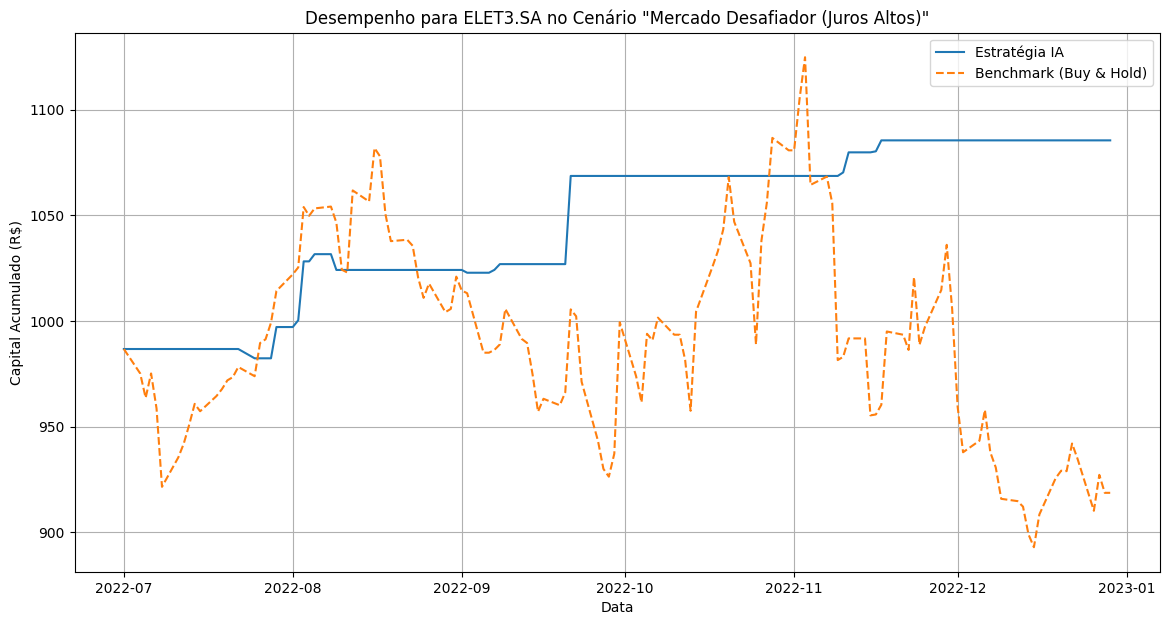


----------------------------------------
IMPORTÂNCIA DOS FATORES: ELET3.SA | Mercado Desafiador (Juros Altos)
               Feature  Importance
1     Volatilidade_10d    0.167922
0          Momentum_5d    0.135746
5      Indice_Ibovespa    0.128831
6           ETF_Brasil    0.126517
3      SMA_10_50_Ratio    0.118220
4               Volume    0.115119
2              RSI_14d    0.112506
7  Taxa_Cambio_USD_BRL    0.095140
----------------------------------------

 EXECUTANDO CENÁRIO: 'Mercado Desafiador (Juros Altos)' PARA O ATIVO: RADL3.SA =
--- Coletando dados para RADL3.SA de 2019-06-01 a 2022-12-31 ---
--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost Multiclasse... ---
Melhores parâmetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
--- Executando backtest final ---

----------------------------------------
RESULTADO FINANCEIRO: RADL3.SA | Cenário: Mercado Desafiador (Juros Altos)
Período de Teste: 2022-07-01 a 2022-12-29
Lucro/Per

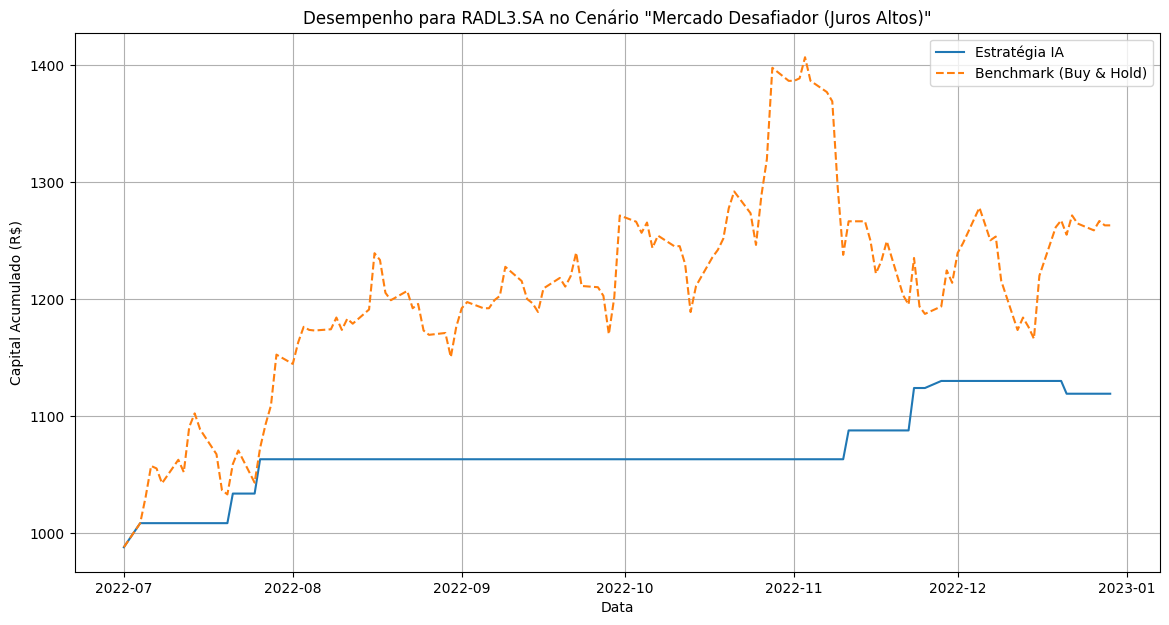


----------------------------------------
IMPORTÂNCIA DOS FATORES: RADL3.SA | Mercado Desafiador (Juros Altos)
               Feature  Importance
0          Momentum_5d    0.150685
2              RSI_14d    0.143011
5      Indice_Ibovespa    0.134764
6           ETF_Brasil    0.128283
1     Volatilidade_10d    0.119238
7  Taxa_Cambio_USD_BRL    0.110989
3      SMA_10_50_Ratio    0.107193
4               Volume    0.105836
----------------------------------------


In [4]:
# ====================================================================
# CÉLULA 4: EXECUÇÃO E ANÁLISE COMPLETA
# ====================================================================

resultados_dos_testes = {}
importancias_dos_fatores = [] 
target = 'Target' 

for cenario_nome, datas in CENARIOS_DE_TESTE.items():
    for ativo in LISTA_DE_ATIVOS:
        print("\n" + "="*80)
        print(f" EXECUTANDO CENÁRIO: '{cenario_nome}' PARA O ATIVO: {ativo} ".center(80, "="))
        print("="*80)

        config = CONFIGURACAO_ATIVOS[ativo]
        
        dados_brutos = coletar_dados(ativo, config['fatores'], config['nomes'], datas['data_inicio_geral'], datas['data_fim_teste'])
        
        if dados_brutos.empty: continue
        df_completo = engenharia_fatores(dados_brutos)
        if df_completo.empty: continue

        df_treino = df_completo.loc[:datas['data_fim_treino']]
        df_validacao = df_completo.loc[datas['data_fim_treino'] + timedelta(days=1) : datas['data_fim_validacao']]
        df_teste = df_completo.loc[datas['data_fim_validacao'] + timedelta(days=1):]
        
        features = ['Momentum_5d', 'Volatilidade_10d', 'RSI_14d', 'SMA_10_50_Ratio', 'Volume'] + config['nomes']
        
        modelo, scaler = otimizar_modelo_xgb(df_treino, features, target)
        
        if modelo:
            # A otimização de limiar não é mais necessária no modelo multiclasse, usamos uma regra de negócio
            df_resultado_final = executar_backtest(modelo, scaler, df_teste.copy(), features, ticker=ativo, cenario=cenario_nome)
            
            if df_resultado_final is not None:
                chave_resultado = f"{ativo}_{cenario_nome}"
                resultados_dos_testes[chave_resultado] = (df_resultado_final, target)
                
                # Analisa e armazena a importância dos fatores para este modelo
                info_features = analisar_feature_importance(modelo, features, ativo, cenario_nome)
                importancias_dos_fatores.append(info_features)


In [5]:
# ====================================================================
# CÉLULA 5: ANÁLISE DE MÉTRICAS DE PERFORMANCE DO MODELO
# ====================================================================

print("\n" + "#"*80)
print(f" ANÁLISE COMPLETA DAS MÉTRICAS DE CLASSIFICAÇÃO ".center(80, "#"))
print("#"*80)

if 'resultados_dos_testes' not in locals() or not resultados_dos_testes:
    print("Nenhum resultado de teste para analisar. Execute a Célula 4 primeiro.")
else:
    for chave, (df_resultado, target_nome) in resultados_dos_testes.items():
        ativo, cenario = chave.split('_', 1)
        print("\n" + "="*80)
        print(f" AVALIANDO MÉTRICAS PARA: {ativo} | CENÁRIO: {cenario} ".center(80, "="))
        print("="*80)
        avaliar_performance_modelo(df_resultado, target_nome)


################################################################################
################ ANÁLISE COMPLETA DAS MÉTRICAS DE CLASSIFICAÇÃO ################
################################################################################

========= AVALIANDO MÉTRICAS PARA: VALE3.SA | CENÁRIO: Crise COVID-19 ==========

----------------------------------------
MÉTRICAS DE CLASSIFICAÇÃO (Decisão de Comprar vs Não Comprar)
              precision    recall  f1-score   support

  Não Compra       0.50      0.94      0.66        67
      Compra       0.20      0.02      0.03        63

    accuracy                           0.49       130
   macro avg       0.35      0.48      0.34       130
weighted avg       0.36      0.49      0.35       130

----------------------------------------

========= AVALIANDO MÉTRICAS PARA: ITUB4.SA | CENÁRIO: Crise COVID-19 ==========

----------------------------------------
MÉTRICAS DE CLASSIFICAÇÃO (Decisão de Comprar vs Não Comprar)
              pr


################################################################################
##### RANKING GERAL DE IMPORTÂNCIA DOS FATORES (MÉDIA DE TODOS OS TESTES) ######
################################################################################
Feature
ETF_Brasil             0.138730
Indice_Ibovespa        0.138165
Volatilidade_10d       0.126022
Momentum_5d            0.120561
SMA_10_50_Ratio        0.118821
RSI_14d                0.117932
Volume                 0.115597
Taxa_Cambio_USD_BRL    0.113857
Preco_Petroleo         0.110997
ETF_China              0.109078
Preco_Minerio_Ferro    0.108393
Name: Importance, dtype: float32


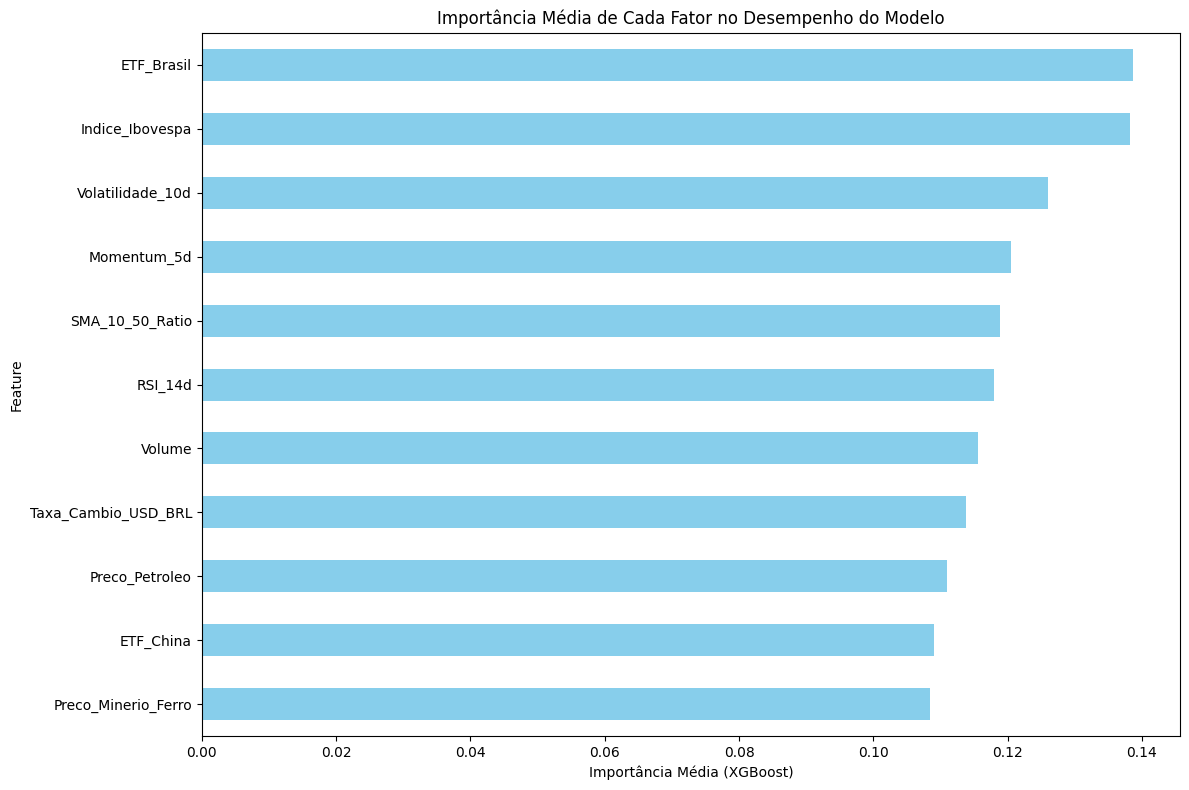

In [6]:
# ====================================================================
# CÉLULA 6: ANÁLISE CONSOLIDADA DA IMPORTÂNCIA DOS FATORES
# ====================================================================

if not importancias_dos_fatores:
    print("Nenhuma análise de importância de fatores para exibir. Execute a Célula 4 primeiro.")
else:
    # Consolida todos os dataframes de importância em um só
    df_consolidado_importancia = pd.concat([info['importancias'] for info in importancias_dos_fatores])
    
    # Calcula a importância média de cada fator em todos os testes
    importancia_media = df_consolidado_importancia.groupby('Feature')['Importance'].mean().sort_values(ascending=False)
    
    print("\n" + "#"*80)
    print(f" RANKING GERAL DE IMPORTÂNCIA DOS FATORES (MÉDIA DE TODOS OS TESTES) ".center(80, "#"))
    print("#"*80)
    print(importancia_media)

    # Plotar o gráfico de importância média
    plt.figure(figsize=(12, 8))
    importancia_media.plot(kind='barh', color='skyblue')
    plt.title('Importância Média de Cada Fator no Desempenho do Modelo')
    plt.xlabel('Importância Média (XGBoost)')
    plt.gca().invert_yaxis() # Fator mais importante no topo
    plt.tight_layout()
    plt.savefig('importancia_geral_fatores.png')
    plt.show()